In [18]:
pip install gurobipy

In [19]:
import numpy as np
import pandas as pd
from gurobipy import *
from scipy.spatial.distance import cdist
from scipy.cluster.vq import kmeans2, whiten
import matplotlib.pyplot as plt

In [20]:
coord_df = pd.read_excel('Spring25Project_Data.xlsx', sheet_name='coordinates') # dataframe
demand_df = pd.read_excel('Spring25Project_Data.xlsx', sheet_name='demands')
nodes = range(demand_df.shape[0])# List of nodes
nodes = list(nodes)
nodes

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38]

In [21]:
coords = coord_df[['x-coordinate', 'y-coordinate']].to_numpy()

In [22]:
distance_matrix = cdist(coords, coords, metric='euclidean')# Build distance matrix

defining demand as unit demand for each nodes

In [23]:
df = coord_df.copy()
df["demand"] = demand_df["Demand"]

In [24]:
df

,Node ID,x-coordinate,y-coordinate,demand
0,0,39,19,0
1,1,79,19,18
2,2,41,79,16
3,3,25,31,22
4,4,63,93,24
5,5,33,5,3
6,6,69,17,19
7,7,57,73,6
8,8,53,75,6
9,9,1,1,6


In [25]:
#import math

#lat = df["y-coordinate"]
#lon = df["x-coordinate"]

#kmeters_per_deg_lat = 111.32

#mean_lat = lat.mean()
#kmeters_per_deg_lon = 111.32 * math.cos(math.radians(mean_lat))


#df["x_m"] = (lon - lon.min()) * kmeters_per_deg_lon
#df["y_m"] = (lat - lat.min()) * kmeters_per_deg_lat


#coords_m = df[['x_m', 'y_m']].values
#distance_matrix = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))


In [26]:
print("Full Distance Matrix:")
print(distance_matrix)

Full Distance Matrix:
[[ 0.         40.         60.03332408 ... 42.75511665 46.69047012
  38.83297568]
 [40.          0.         71.02112362 ...  8.24621125 79.62411695
  75.2861209 ]
 [60.03332408 71.02112362  0.         ... 78.89233169 42.80186912
  50.99019514]
 ...
 [42.75511665  8.24621125 78.89233169 ...  0.         85.08818954
  79.84985911]
 [46.69047012 79.62411695 42.80186912 ... 85.08818954  0.
  12.        ]
 [38.83297568 75.2861209  50.99019514 ... 79.84985911 12.
   0.        ]]


In [28]:
nodes = list(range(len(df)))
demand = df["demand"].values
total_demand = df["demand"].sum()
vehicle_capacity = 85 # vehicle capacity
num_vehicles = int(np.ceil(total_demand / vehicle_capacity)) # number of vehicles
num_vehicles

7

In [29]:
#Create a new model
vrp = Model("vrp_model")

In [30]:
#Create variables
x = vrp.addVars(nodes, nodes, lb = 0,vtype = GRB.BINARY,name = 'x')
u = vrp.addVars(nodes, lb = 0,vtype = GRB.INTEGER,name = 'u')

In [31]:
#Add constraint
vrp.addConstrs(((quicksum(x[i,j] for j in nodes if j != i) == 1) for i in nodes if i != 0), name = 'outflow');
vrp.addConstrs(((quicksum(x[i,j] for i in nodes if i != j) == 1) for j in nodes if j != 0), name = 'inflow');
vrp.addConstr(((quicksum(x[0,j] for j in nodes) == num_vehicles)), name = 'depot_out');
vrp.addConstr(((quicksum(x[i,0] for i in nodes) == num_vehicles)), name = 'depot_in');
vrp.addConstrs(((u[i] - u[j] + vehicle_capacity*x[i,j] <= vehicle_capacity - demand[j]) for i in nodes for j in nodes if i!=j and i != 0 and j != 0), name = 'subtour_elimination');
vrp.addConstrs(((u[i] <= vehicle_capacity) for i in nodes), name = 'vehiclecapacity_upper');
vrp.addConstrs(((u[i] >= demand[i]) for i in nodes), name = 'vehiclecapacity_lower');
vrp.addConstr(u[0] == 0, name="depot_load")


<gurobi.Constr *Awaiting Model Update*>

In [32]:
#set objective function
vrp.setObjective((quicksum(distance_matrix[i][j]*x[i,j] for i in nodes for j in nodes if i != j)),GRB.MINIMIZE)

In [33]:
vrp.setParam("TimeLimit", 900)   # time limit
#vrp.setParam("OutputFlag", 0)     # do not print on console

Set parameter TimeLimit to value 900


In [34]:
vrp.update()
vrp.optimize()

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  900

Optimize a model with 1563 rows, 1560 columns and 7263 nonzeros
Model fingerprint: 0x82c5415f
Variable types: 0 continuous, 1560 integer (1521 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+01]
  Objective range  [4e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+01]
Presolve removed 111 rows and 71 columns
Presolve time: 0.03s
Presolved: 1452 rows, 1489 columns, 7024 nonzeros
Variable types: 0 continuous, 1489 integer (1451 binary)

Root relaxation: objective 5.350665e+02, 138 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

    

In [35]:
status = vrp.status

object_Value = vrp.objVal

print()
print("model status is: ", status)
print()
print("Objective value is: ", object_Value)


model status is:  9

Objective value is:  914.2726404122584


In [36]:
# Print decision varibales which are not zeros
if status !=3 and status != 4:
    for v in vrp.getVars():
        if vrp.objVal < 1e+99  and v.x!=0:
            print('%s %f'%(v.Varname,v.x))

x[0,5] 1.000000
x[0,13] 1.000000
x[0,14] 1.000000
x[0,15] 1.000000
x[0,20] 1.000000
x[0,30] 1.000000
x[0,36] 1.000000
x[1,6] 1.000000
x[2,0] 1.000000
x[3,24] 1.000000
x[4,16] 1.000000
x[5,29] 1.000000
x[6,11] 1.000000
x[7,8] 1.000000
x[8,4] 1.000000
x[9,12] 1.000000
x[10,0] 1.000000
x[11,26] 1.000000
x[12,38] 1.000000
x[13,0] 1.000000
x[14,35] 1.000000
x[15,3] 1.000000
x[16,10] 1.000000
x[17,0] 1.000000
x[18,21] 1.000000
x[19,2] 1.000000
x[20,32] 1.000000
x[21,23] 1.000000
x[22,18] 1.000000
x[23,17] 1.000000
x[24,0] 1.000000
x[25,33] 1.000000
x[26,0] 1.000000
x[27,34] 1.000000
x[28,9] 1.000000
x[29,28] 1.000000
x[30,7] 1.000000
x[31,0] 1.000000
x[32,27] 1.000000
x[33,19] 1.000000
x[34,22] 1.000000
x[35,25] 1.000000
x[36,1] 1.000000
x[37,31] 1.000000
x[38,37] 1.000000
u[1] 33.000000
u[2] 78.000000
u[3] 38.000000
u[4] 50.000000
u[5] 3.000000
u[6] 52.000000
u[7] 20.000000
u[8] 26.000000
u[9] 36.000000
u[10] 85.000000
u[11] 70.000000
u[12] 52.000000
u[13] 72.000000
u[14] 7.000000
u[15] 16.

In [37]:
# printing routes
if status != 3 and status != 4:
    vis = []
    Sol_x = np.zeros([len(nodes), len(nodes)])
    for i in nodes:
        for j in nodes:
            if vrp.objVal < 1e+99:
                Sol_x[i,j] = x[i,j].getAttr("X")
            else:
                error_status = True
                ofvv = 1e+99
            if 1 - 0.00001 <= Sol_x[i,j] <= 1 + 0.00001:
                vis.append((i,j))

visited = np.array(vis)
solution = []
if visited[0][0] == 0:
    sol = [visited[0][0], visited[0][1]]
elif visited[0][0] !=0 and visited[0][1] == 0:
    sol = [visited[0][1], visited[0][0]]
else:
    print('First tuple should include depot 0')
visited = np.delete(visited,0, axis = 0)

solution = []
for i in visited:
    try:
        next_ind = int(np.where(visited[:,0] == sol[-1])[0])
        sol.append(visited[next_ind][1])
        visited = np.delete(visited,next_ind, axis = 0)
    except:
        next_ind = int(np.where(visited[:,1] == sol[-1])[0])
        sol.append(visited[next_ind][0])
        visited = np.delete(visited,next_ind, axis = 0)

    if sol[0] == sol[-1]:
        sol = np.asarray(sol)
        solution.append(sol)
        used = []
        for j in solution:
            for k in j:
                used.append(k)
        remain = list(set(nodes) - set(used))
        if remain == []:
            break
        sol=[visited[0][0], visited[0][1]]
        visited = np.delete(visited,0, axis = 0)

print('optimal Solution is:', solution)

optimal Solution is: [array([ 0,  5, 29, 28,  9, 12, 38, 37, 31,  0]), array([ 0, 13,  0]), array([ 0, 14, 35, 25, 33, 19,  2,  0]), array([ 0, 15,  3, 24,  0]), array([ 0, 20, 32, 27, 34, 22, 18, 21, 23, 17,  0]), array([ 0, 30,  7,  8,  4, 16, 10,  0]), array([ 0, 36,  1,  6, 11, 26,  0])]


<ipython-input-37-4fce4756279f>:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_ind = int(np.where(visited[:,0] == sol[-1])[0])


In [38]:
combination_name = "Gurobi Optimal Solution"
cost = round(object_Value, 2)
time_taken = round(vrp.Runtime, 2)
status_str = vrp.Status
status_dict = {
    1: "Model Loaded",
    2: "Optimal",
    3: "Infeasible",
    4: "Infeasible or Unbounded",
    5: "Unbounded",
    6: "Cutoff",
    9: "Time Limit Reached",
    11: "Interrupted"
}
status_name = status_dict.get(status_str, "Other")

print("Model Status:", status_name)
print("\n{:<40} {:<10} {:<10} {:<10}".format("Combination", "Cost", "Time", "Status"))
print("-" * 75)
print("{:<40} {:<10} {:<10} {:<10}".format(combination_name, cost, f"{time_taken} sec", status_name))


Model Status: Time Limit Reached

Combination                              Cost       Time       Status    
---------------------------------------------------------------------------
Gurobi Optimal Solution                  914.27     900.03 sec Time Limit Reached


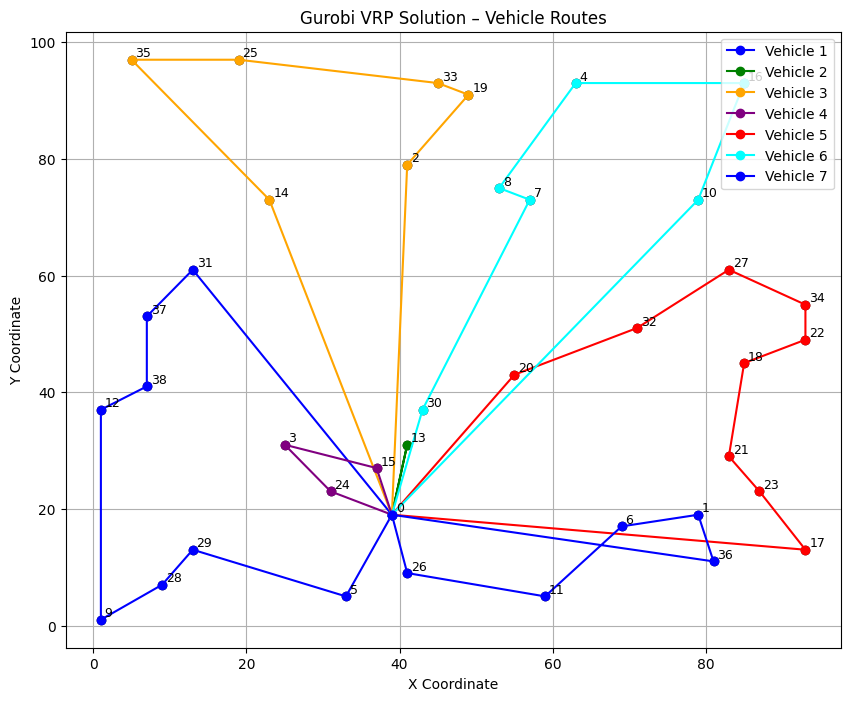

In [39]:
colors = ['blue', 'green', 'orange', 'purple', 'red', 'cyan']

plt.figure(figsize=(10, 8))

plt.scatter(coords[:, 0], coords[:, 1], c='black')
for i, (x, y) in enumerate(coords):
    plt.text(x + 0.5, y + 0.5, str(i), fontsize=9)

for i, route in enumerate(solution):
    route_coords = coords[route]
    plt.plot(route_coords[:, 0], route_coords[:, 1], marker='o', label=f'Vehicle {i+1}', color=colors[i % len(colors)])

plt.title("Gurobi VRP Solution – Vehicle Routes")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.legend()
plt.show()


In [40]:
print("{:<10} | {:<40} | {:<25}".format("Vehicle", "Route", "Load Utilization"))
print("-" * 85)

for i, route in enumerate(solution):
    customer_ids = [node for node in route if node != 0]
    total_load = demand[customer_ids].sum()
    utilization = round((total_load / vehicle_capacity) * 100, 1)

    route_str = ' → '.join(map(str, route))
    print(f"Vehicle {i+1:<2} | Route: {route_str:<40} | Load: {total_load} / {vehicle_capacity} ({utilization}%)")

Vehicle    | Route                                    | Load Utilization         
-------------------------------------------------------------------------------------
Vehicle 1  | Route: 0 → 5 → 29 → 28 → 9 → 12 → 38 → 37 → 31 → 0 | Load: 74 / 85 (87.1%)
Vehicle 2  | Route: 0 → 13 → 0                               | Load: 72 / 85 (84.7%)
Vehicle 3  | Route: 0 → 14 → 35 → 25 → 33 → 19 → 2 → 0       | Load: 78 / 85 (91.8%)
Vehicle 4  | Route: 0 → 15 → 3 → 24 → 0                      | Load: 60 / 85 (70.6%)
Vehicle 5  | Route: 0 → 20 → 32 → 27 → 34 → 22 → 18 → 21 → 23 → 17 → 0 | Load: 77 / 85 (90.6%)
Vehicle 6  | Route: 0 → 30 → 7 → 8 → 4 → 16 → 10 → 0         | Load: 80 / 85 (94.1%)
Vehicle 7  | Route: 0 → 36 → 1 → 6 → 11 → 26 → 0             | Load: 85 / 85 (100.0%)


In [41]:
def verify_vrp_solution(routes, demands, vehicle_capacity, n_customers):
    visited_customers = set()
    valid = True

    for i, route in enumerate(routes):
        if route[0] != 0 or route[-1] != 0:
            print(f"Vehicle {i+1}: Route does not start and end at the depot → {route}")
            valid = False

        total_demand = 0
        for node in route[1:-1]:
            if node == 0:
                print(f"Vehicle {i+1}: Intermediate depot found in the route → {route}")
                valid = False
            total_demand += demands[node]
            if node in visited_customers:
                print(f"Customer {node} is visited more than once!")
                valid = False
            else:
                visited_customers.add(node)

        if total_demand > vehicle_capacity:
            print(f"Vehicle {i+1}: Capacity exceeded → {total_demand} > {vehicle_capacity}")
            valid = False

    if len(visited_customers) != n_customers:
        print(f"Not all customers are visited. Expected: {n_customers}, Actual: {len(visited_customers)}")
        valid = False

    if valid:
        print("VRP solution is feasible! All conditions are satisfied.")
    else:
        print("VRP solution is not feasible. Please check the violations above.")

    return valid

verify_vrp_solution(solution, df["demand"].values, 85, 38)

VRP solution is feasible! All conditions are satisfied.


True